<a href="https://colab.research.google.com/github/diwakarg05/Neural-Network/blob/main/third_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("vikrishnan/iris-dataset")

print(os.listdir(path))  # check files

file_path = os.path.join(path, "iris.data.csv")
df = pd.read_csv(file_path)

# Add column names
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

print(df.head())

Using Colab cache for faster access to the 'iris-dataset' dataset.
['iris.data.csv']
   sepal_length  sepal_width  petal_length  petal_width      species
0           4.9          3.0           1.4          0.2  Iris-setosa
1           4.7          3.2           1.3          0.2  Iris-setosa
2           4.6          3.1           1.5          0.2  Iris-setosa
3           5.0          3.6           1.4          0.2  Iris-setosa
4           5.4          3.9           1.7          0.4  Iris-setosa


In [ ]:
# Features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Encode labels (Setosa, Versicolor, Virginica → 0,1,2)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# One-hot encoding
y = to_categorical(y)

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Build model (Sequential API)
model = Sequential()
model.add(Dense(8, input_dim=4, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    validation_data=(X_test, y_test),
                    verbose=1)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3866 - loss: 1.0733 - val_accuracy: 0.4000 - val_loss: 1.2115
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4454 - loss: 1.0110 - val_accuracy: 0.4667 - val_loss: 1.1275
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4706 - loss: 0.9576 - val_accuracy: 0.5667 - val_loss: 1.0536
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5546 - loss: 0.9094 - val_accuracy: 0.6000 - val_loss: 0.9935
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6387 - loss: 0.8670 - val_accuracy: 0.6000 - val_loss: 0.9402
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6891 - loss: 0.8262 - val_accuracy: 0.6000 - val_loss: 0.8894
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6975 - loss: 0.7872 - val_accuracy: 0.6000 - val_loss: 0.8414
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6975 - loss: 0.7497 - val_accuracy: 0.6000 - 

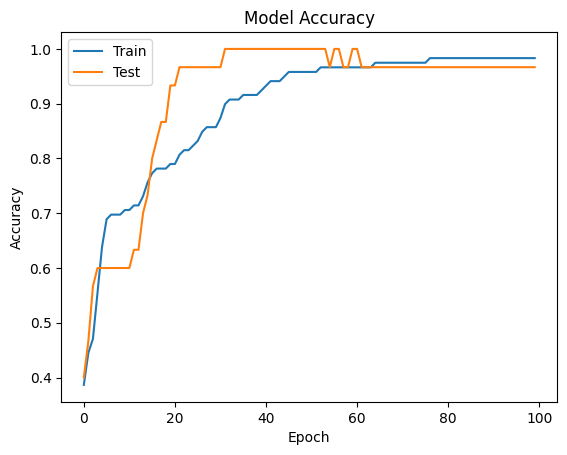

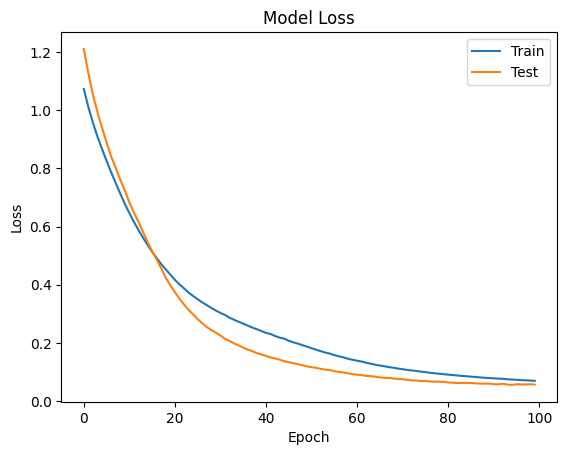

In [ ]:
# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'])
plt.show()